In [1]:
import sqlite3

# Create SQLite database file
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

# Create table
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

# Insert sample data
sample_data = [
    ('Apple', 10, 1.5),
    ('Banana', 20, 0.5),
    ('Orange', 15, 1.0),
    ('Apple', 5, 1.5),
    ('Banana', 10, 0.5),
    ('Orange', 5, 1.0)
]

cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)
conn.commit()
conn.close()


In [2]:
import pandas as pd

# Reconnect to the database
conn = sqlite3.connect("sales_data.db")

# Run SQL query
query = """
SELECT product,
       SUM(quantity) AS total_qty,
       SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""

df = pd.read_sql_query(query, conn)
print("Sales Summary:")
print(df)

conn.close()


Sales Summary:
  product  total_qty  revenue
0   Apple         15     22.5
1  Banana         30     15.0
2  Orange         20     20.0


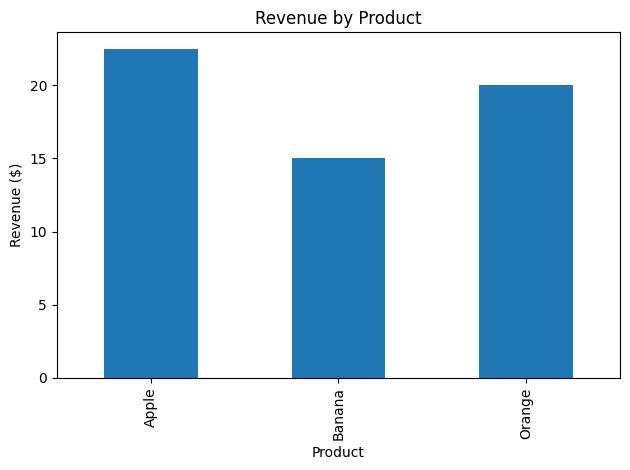

In [3]:
import matplotlib.pyplot as plt

# Plot revenue by product
df.plot(kind='bar', x='product', y='revenue', legend=False)
plt.title("Revenue by Product")
plt.ylabel("Revenue ($)")
plt.xlabel("Product")
plt.tight_layout()
plt.show()


In [4]:
plt.savefig("sales_chart.png")


<Figure size 640x480 with 0 Axes>